# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [5]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
df = pd.read_json("hf://datasets/SetFit/20_newsgroups/train.jsonl", lines=True)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [6]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [8]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["sci.space", "rec.sport.baseball", "talk.politics.guns"]

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'rec.sport.baseball', 'talk.politics.guns']
Filtered dataset size: 1736

Distribution:
label_text
rec.sport.baseball    597
sci.space             593
talk.politics.guns    546
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

I chose sci.space, rec.sport.baseball, and talk.politics.guns because they are very different topics: science, sports, and politics. I expect each one to have its own specific vocabulary, like technical terms for space, game-related words for baseball, and legal or political terms for guns. I picked them because this contrast makes it easier to see how well models like BoW and TF-IDF can distinguish between topics.

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [9]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)           # Remove emails
    text = re.sub(r'http\S+|www\S+', '', text)    # Remove URLs
    text = re.sub(r'\d+', '', text)               # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()      # Remove extra whitespace
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [11]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')  # needed in newer versions
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    # Step 1: Basic cleaning
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Step 5: Remove short words
    tokens = [t for t in tokens if len(t) >= 3]

    # Step 6: Join back
    return ' '.join(tokens)
# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [12]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
article tom baker understanding expected error basically known bug warning system software thing checked dont right value yet arent set till launch suchlike rather fix code possibly introduce new bug tell crew see warning liftoff ignore


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

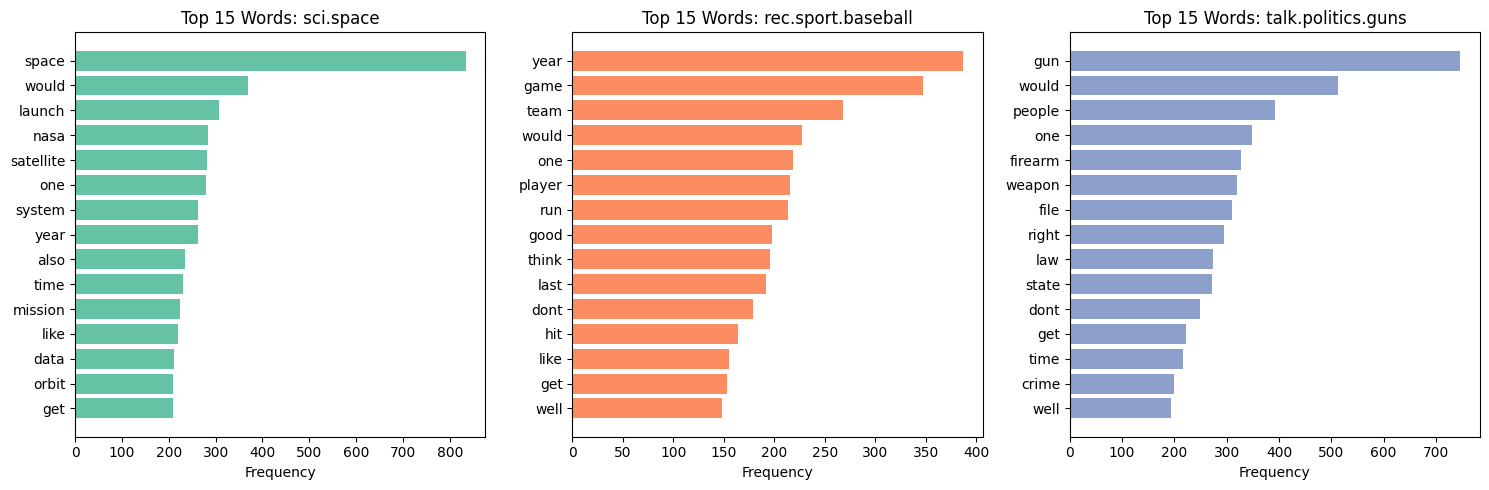

In [13]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

Category 1 (sci.space):

Unique words: space, launch, nasa

Category 2 (rec.sport.baseball):

Unique words: team, game, player

Category 3 (talk.politics.guns):

Unique words: gun, firearm, weapon, crime

Shared words and explanation:
Words like "would", "one", and "get" appear in all categories because they are common words used in general sentences, not specific to any topic.

Topic guessing analysis:
Yes, for the first two categories it is easy to guess. Words like "space", "launch", and "nasa" clearly refer to sci.space, and "game", "team", and "year" clearly refer to sports. For the third one, words like "gun" and "weapon" suggest the topic, but it is less obvious that it is specifically about politics without more context.

### C.2 Word Clouds

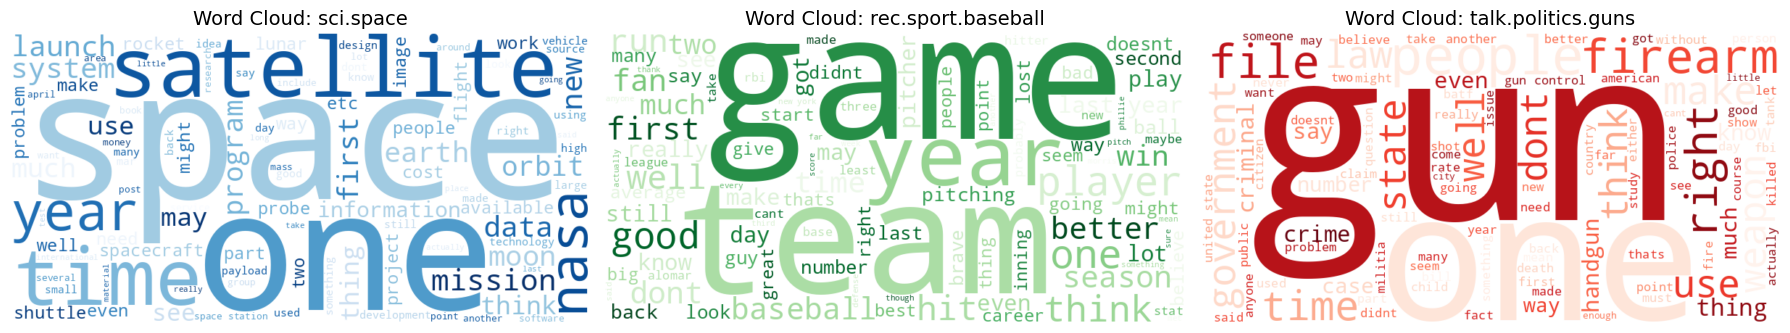

In [14]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

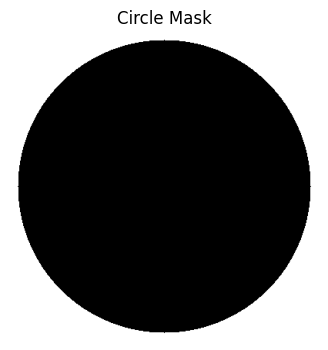

In [49]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = 255- create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

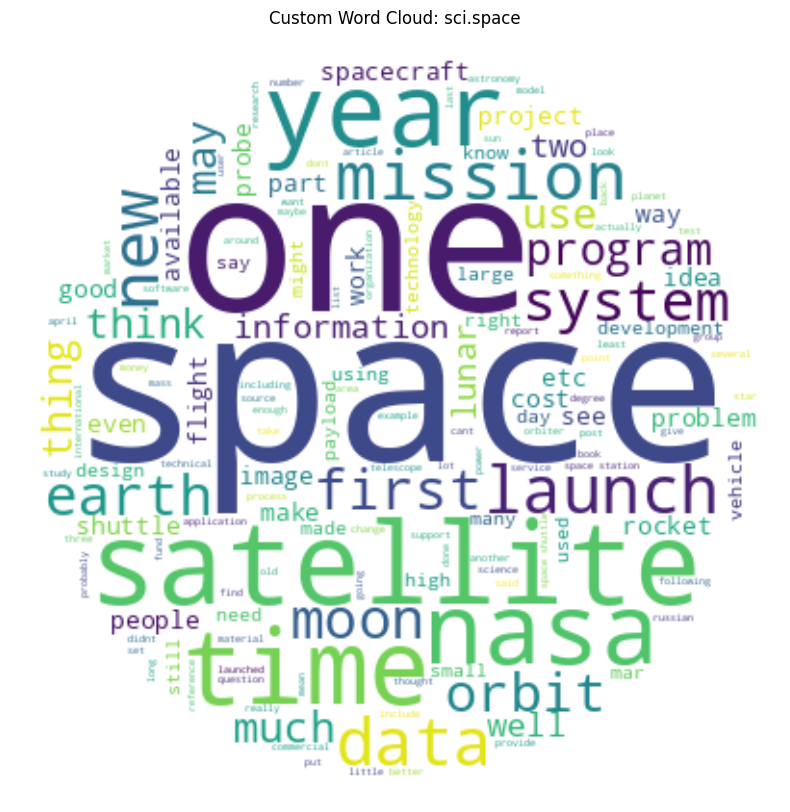

In [50]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = "sci.space"

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
wordcloud_masked = WordCloud(
    width=800,
    height=800,
    background_color='white',
    mask=circle_mask,
    colormap='viridis',
    max_words=150
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [31]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [32]:
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1736, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['ability' 'able' 'access' 'accident' 'according' 'account' 'act' 'action'
 'activity' 'actually' 'add' 'addition' 'address' 'advantage'
 'advertising' 'aerospace' 'age' 'agency' 'agent' 'ago']


### Exercise D.2: Document Similarity with BoW

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(bow_matrix_full)
print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1736, 1736)


In [37]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

sim_matrix_no_diag = similarity_matrix.copy()
np.fill_diagonal(sim_matrix_no_diag, -1)

flat_idx = np.argmax(sim_matrix_no_diag)
most_similar_idx = np.unravel_index(flat_idx, sim_matrix_no_diag.shape)
most_similar_score = sim_matrix_no_diag[most_similar_idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(294), np.int64(1207))
Similarity score: 0.9972792357789938

Document 1 category: rec.sport.baseball
Document 2 category: rec.sport.baseball


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [ ]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

**YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. Same or different category: They are from the same category, which is rec.sport.baseball.

2. What makes them similar: They are similar because they use almost the same baseball vocabulary and talk about the same type of subject. Since both documents are about baseball, they probably contain repeated words related to games, players, teams, or seasons. This explains why their similarity score is extremely high.

3. Is BoW meaningful here: Yes, BoW is meaningful here because it correctly identified two documents from the same category as very similar. It works well when documents share a lot of topic-specific words. However, it also has limits because it only counts words and ignores word order and deeper meaning.

---

## Part E: TF-IDF Representation

In [38]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [39]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [40]:
tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])
print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1253, 1000)


In [41]:
def get_top_tfidf_words(category, n=10):
    # 1. Get indices of documents in this category
    cat_indices = df_filtered[df_filtered['label_text'] == category].index.tolist()

    # 2. Get their TF-IDF vectors
    cat_tfidf = tfidf_matrix_full[cat_indices]

    # 3. Compute mean TF-IDF across documents
    mean_scores = np.asarray(cat_tfidf.mean(axis=0)).flatten()

    # 4. Return top n words
    feature_names = tfidf_vectorizer_full.get_feature_names_out()
    top_indices = mean_scores.argsort()[::-1][:n]
    return [(feature_names[i], mean_scores[i]) for i in top_indices]

for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    for word, score in top_words:
        print(f"  {word}: {score:.4f}")


Top TF-IDF words for 'sci.space':
  space: 0.0742
  would: 0.0390
  nasa: 0.0309
  launch: 0.0302
  like: 0.0297
  orbit: 0.0290
  one: 0.0269
  moon: 0.0264
  earth: 0.0246
  system: 0.0246

Top TF-IDF words for 'rec.sport.baseball':
  game: 0.0690
  year: 0.0608
  team: 0.0545
  player: 0.0517
  run: 0.0410
  baseball: 0.0387
  last: 0.0359
  hit: 0.0356
  good: 0.0351
  fan: 0.0347

Top TF-IDF words for 'talk.politics.guns':
  gun: 0.0739
  would: 0.0487
  people: 0.0463
  weapon: 0.0420
  right: 0.0376
  dont: 0.0351
  one: 0.0345
  law: 0.0330
  government: 0.0300
  get: 0.0292


### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. Words in TF-IDF but not counts:
* sci.space: moon, earth : these are important topic-specific terms but not frequent enough overall to rank in raw counts, yet TF-IDF correctly surfaces them as distinctive.
* rec.sport.baseball: baseball, fan : surprisingly absent from raw counts, but TF-IDF identifies them as highly characteristic of the category.
* talk.politics.guns: government : a meaningful political term that raw counts missed, replaced by more generic high-frequency words.

2. Words in counts but not TF-IDF: * sci.space: satellite, also, time, mission, data, year, get : some are topic-relevant (satellite, mission, data) but too common across all three categories to score well in TF-IDF; others (also, get) are generic filler words.
* rec.sport.baseball: would, one, think, dont, get, like, well : almost entirely generic conversational words that appear heavily across all categories, so TF-IDF correctly penalizes them.
* talk.politics.guns: firearm, file, state, time, crime, well : interestingly firearm and crime are topic-relevant but get outscored by even more distinctive terms; file is likely a preprocessing artifact.

3. Which method is better and why:
- TF-IDF better captures each category's topic by rewarding words that are **distinctive** to a category, not just frequent overall.
- Raw counts are polluted by generic words like `would`, `one`, `get` that rank highly in **every** category and mean nothing topically.
- TF-IDF correctly surfaces words like `moon`/`earth` (sci.space), `baseball`/`fan` (baseball), `government` (guns) that raw counts miss entirely.

---

## Part F: N-grams and Next Word Prediction

In [43]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [44]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [45]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    bv = CountVectorizer(ngram_range=(2, 2), max_features=500, min_df=3)
    bigram_matrix = bv.fit_transform(texts)

    bigram_counts = bigram_matrix.sum(axis=0).A1
    bigram_features = bv.get_feature_names_out()
    top_bigrams = sorted(zip(bigram_features, bigram_counts), key=lambda x: -x[1])

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 56
  anonymous ftp: 36
  commercial space: 31
  remote sensing: 30
  launch vehicle: 27
  national space: 26
  nasa ames: 24
  air force: 23
  space technology: 21
  black hole: 20
  launch system: 20
  space program: 20
  available anonymous: 19
  earth orbit: 19

Top bigrams for 'rec.sport.baseball':
  last year: 94
  new york: 47
  home run: 36
  red sox: 31
  dont know: 30
  major league: 24
  dont think: 23
  los angeles: 21
  san francisco: 20
  world series: 19
  pitching staff: 18
  san diego: 18
  blue jay: 17
  run scored: 17
  hall fame: 16

Top bigrams for 'talk.politics.guns':
  gun control: 109
  united state: 72
  second amendment: 55
  dont know: 32
  dont think: 31
  assault weapon: 30
  bear arm: 30
  gun owner: 29
  waiting period: 29
  law enforcement: 28
  keep bear: 27
  homicide rate: 26
  tear gas: 25
  gun law: 23
  control law: 21


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [46]:
class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}
        self.unigram_counts = {}

    def train(self, texts):
        for text in texts:
            words = text.split()
            for word in words:
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1
            for w1, w2 in zip(words[:-1], words[1:]):
                if w1 not in self.bigram_counts:
                    self.bigram_counts[w1] = {}
                self.bigram_counts[w1][w2] = self.bigram_counts[w1].get(w2, 0) + 1

    def predict_next(self, word, top_n=5):
        if word not in self.bigram_counts:
            return []
        followers = self.bigram_counts[word]
        total = self.unigram_counts.get(word, 1)
        probs = [(w2, count / total) for w2, count in followers.items()]
        probs.sort(key=lambda x: -x[1])
        return probs[:top_n]

predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [47]:
# Test words relevant to the chosen categories
test_words = ["space", "baseball", "gun", "orbit", "player"]

print("Next Word Predictions:")
print("=" * 40)
for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'space' ->
  station: 0.084
  shuttle: 0.068
  technology: 0.026
  program: 0.024
  science: 0.022

'baseball' ->
  bat: 0.045
  fanatic: 0.038
  player: 0.038
  team: 0.038
  fan: 0.030

'gun' ->
  control: 0.143
  owner: 0.038
  law: 0.030
  ownership: 0.024
  would: 0.017

'orbit' ->
  moon: 0.024
  trajectory: 0.019
  earth: 0.019
  around: 0.015
  vehicle: 0.015

'player' ->
  still: 0.014
  team: 0.014
  hall: 0.014
  point: 0.014
  maybe: 0.014


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

**1. Good predictions:**
- `space` → `station`, `shuttle`: highly sensible, these are the most classic collocations in aerospace vocabulary.
- `gun` → `control`, `owner`, `law`: all three reflect the political/legal framing typical of *talk.politics.guns* discussions.

**Bad predictions:**
- `player` → `still`, `maybe`, `point`: completely generic words with no baseball meaning, likely because "player" appears in varied sentence contexts.
- `baseball` → `fanatic`: unusual collocation, almost certainly caused by one or two highly repetitive posts skewing the bigram count.

**2. Limitations:**
- Only looks **one word back** — has no sense of sentence context or topic.
- Highly sensitive to **repeated posts** (e.g. `baseball fanatic` likely from a single prolific user).
- Assigns equal flat probabilities when a word has few observations (e.g. all `player` predictions score exactly 0.014).

**3. Improvement ideas:**
- Use **trigrams or higher-order n-grams** to capture more context (e.g. "space shuttle" → `launch`).
- Apply **Laplace/add-k smoothing** to handle rare bigrams more gracefully instead of flat probabilities.
- Use a **neural language model** (e.g. an LSTM or transformer) which learns long-range dependencies and generalizes far better to unseen word pairs.

---

## Part G: Document Correlation Matrix

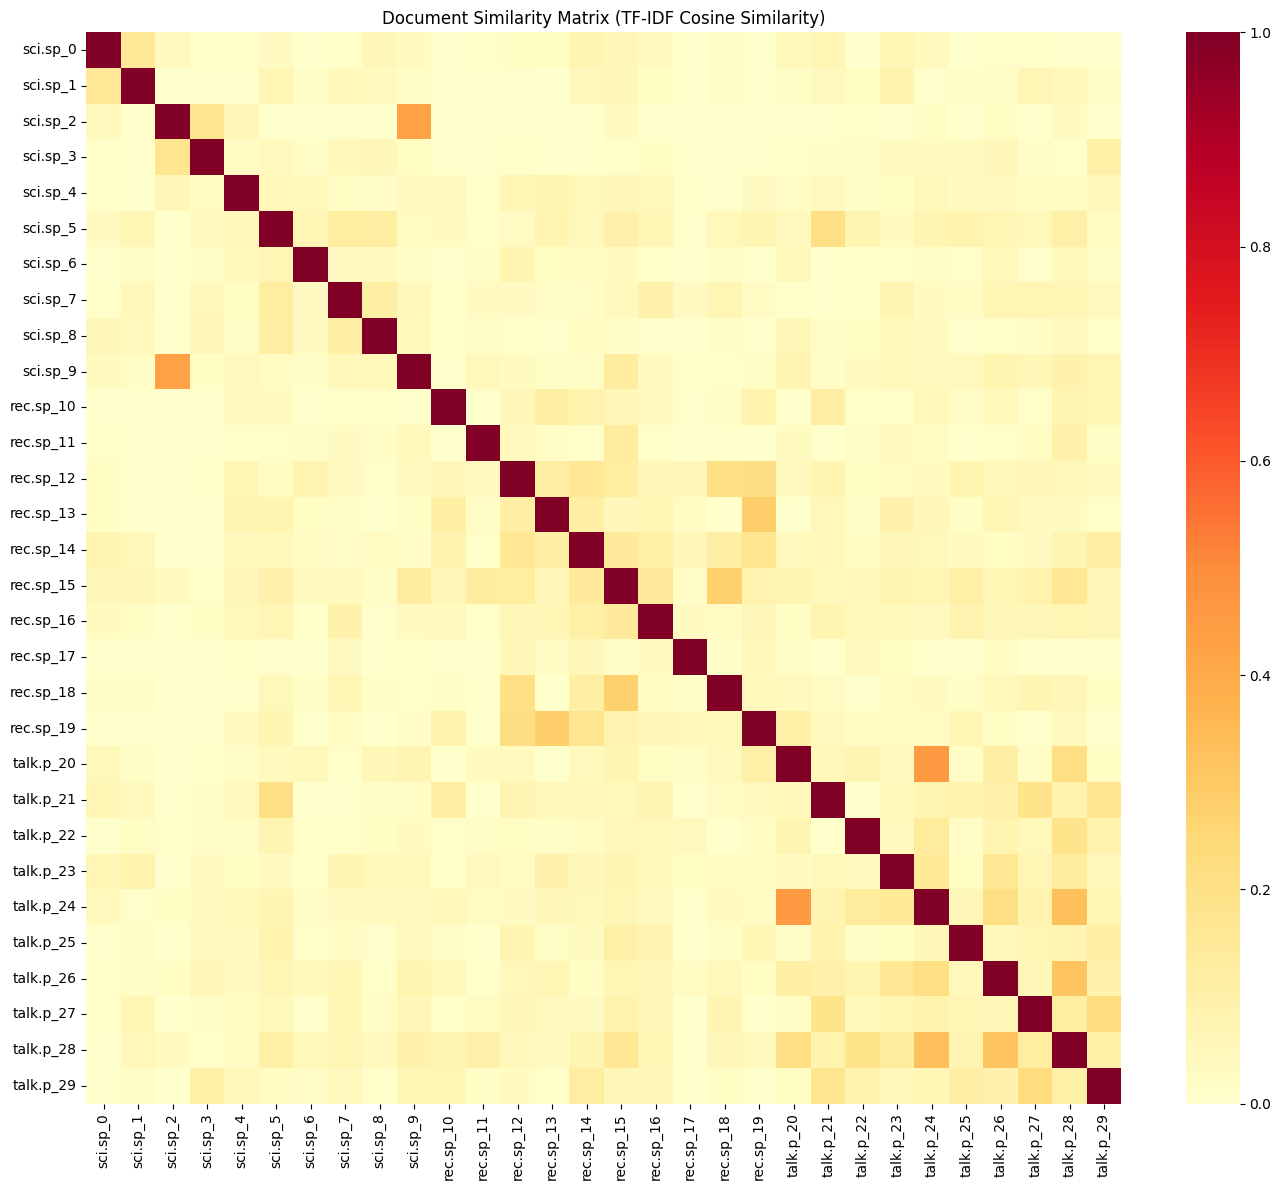

In [48]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. Clustering observation: ...

2. Most/Least similar category pairs: ...

3. Surprising similarities: ...

**YOUR ANSWER:**

**1. Clustering observation:**
Yes, but unevenly. The three diagonal blocks (sci.space 0–9, rec.sport.baseball 10–19, talk.politics.guns 20–29) are clearly visible as darker squares, confirming that same-category documents are more similar to each other than to documents from other categories. However, the *talk.politics.guns* block is noticeably less tight than the other two, suggesting more vocabulary diversity within that category.

**2. Most/Least similar category pairs:**
- **Most similar**: `rec.sport.baseball` and `talk.politics.guns` — there are scattered orange patches in their off-diagonal region (e.g. around rec.sp_13–15 vs talk.p_19–20), likely due to shared conversational vocabulary.
- **Least similar**: `sci.space` and `rec.sport.baseball`: the top-right quadrant is almost entirely pale yellow, indicating near-zero vocabulary overlap between technical space content and sports discussion.

**3. Surprising similarities:**
- `sci.sp_2` shows an unexpectedly high similarity with `rec.sp_13` (the bright orange square off-diagonal in the top section) : this is surprising given they belong to completely different categories. It likely reflects two short or generic documents that share common conversational words rather than any real topical overlap, which illustrates a key weakness of TF-IDF cosine similarity on short texts.
- Several `talk.politics.guns` documents show moderate similarity with each other across the block (orange patches at talk.p_24–28), suggesting some posts are part of the same thread or reply chain sharing repeated quoted text.

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
